In [76]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from nltk.stem import PorterStemmer
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv


In [70]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()



[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [64]:
df=pd.read_csv("/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv")
df.head(100)

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral
...,...,...,...,...,...,...
95,MAHARAJA WHITELINE 65 L Desert Air Cooler?????...,7999,5,great product,very good,positive
96,MAHARAJA WHITELINE 65 L Desert Air Cooler?????...,7999,5,highly recommended,good product delivery on time,positive
97,MAHARAJA WHITELINE 65 L Desert Air Cooler?????...,7999,5,must buy!,nice product deliver in time,positive
98,MAHARAJA WHITELINE 65 L Desert Air Cooler?????...,7999,5,terrific purchase,i honestly liked the productbest desert cooler...,positive


In [28]:
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df["Sentiment"].value_counts())

(205052, 6)
['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB
None
Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


In [29]:

model = LogisticRegression(class_weight='balanced')

In [30]:
print (df.describe())
print(df.isnull().sum())

                                             product_name product_price  \
count                                              205052        205052   
unique                                                958           525   
top     cello Pack of 18 Opalware Cello Dazzle Lush Fi...          1299   
freq                                                 6005          9150   

          Rate     Review Summary Sentiment  
count   205052     180388  205041    205052  
unique       8       1324   92923         3  
top          5  wonderful    good  positive  
freq    118765       9016   17430    166581  
product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64


In [31]:
print(df['Review'].isnull().sum())
print(df['Summary'].isnull().sum())

24664
11


In [32]:
print(df.dropna(subset=['Review'], inplace=True))
print(df.dropna(subset=['Summary'], inplace=True))

None
None


In [34]:
#class balance check
print(df.head(4)[["product_name",  "Rate", "Review",  "Sentiment"]])

                                        product_name Rate           Review  \
0  Candes 12 L Room/Personal Air Cooler??????(Whi...    5           super!   
1  Candes 12 L Room/Personal Air Cooler??????(Whi...    5          awesome   
2  Candes 12 L Room/Personal Air Cooler??????(Whi...    3             fair   
3  Candes 12 L Room/Personal Air Cooler??????(Whi...    1  useless product   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  negative  


In [35]:
for sent in ["positive", "neutral", "negative"]:
    sample = df[df.Sentiment==sent]["Review"].iloc[0]
    print(f"\n{sent.upper()}:\n{sample}")


POSITIVE:
super!

NEUTRAL:
fair

NEGATIVE:
useless product


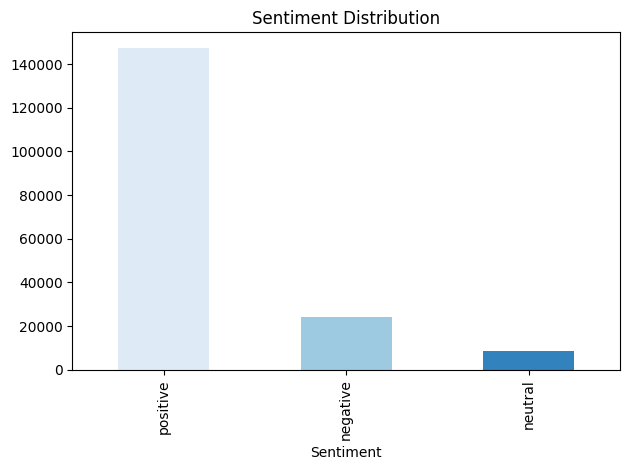

In [36]:
#distribution plot
df["Sentiment"].value_counts().plot(kind="bar", color = ["#deebf7", "#9ecae1","#3182bd"], title = "Sentiment Distribution")
plt.tight_layout()
plt.show()

In [37]:
def preprocess(text):
    text   = text.lower()
    text   = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t)
              for t in tokens
              if t not in stop_words
              and len(t) > 2]
    return ' '.join(tokens)

   

In [38]:
df["clean_text"] = df["Review"].astype(str).apply(preprocess)

In [39]:
print(df[["Review","clean_text"]]. head(10))

               Review          clean_text
0              super!               super
1             awesome             awesome
2                fair                fair
3     useless product     useless product
4                fair                fair
5             awesome             awesome
6  highly recommended  highly recommended
7                nice                nice
8      unsatisfactory      unsatisfactory
9     worth the money         worth money


In [40]:
#join all clean_text per sentiment
pos_words=''.join(df[df.Sentiment=='positive']['clean_text'])
neg_words=''.join(df[df.Sentiment=='negative']['clean_text'])
neu_words=''.join(df[df.Sentiment=='neutral']['clean_text'])

In [41]:
pos_split=Counter(pos_words.split()).most_common(20)
neg_split=Counter(neg_words.split()).most_common(20)
neu_split=Counter(neu_words.split()).most_common(20)

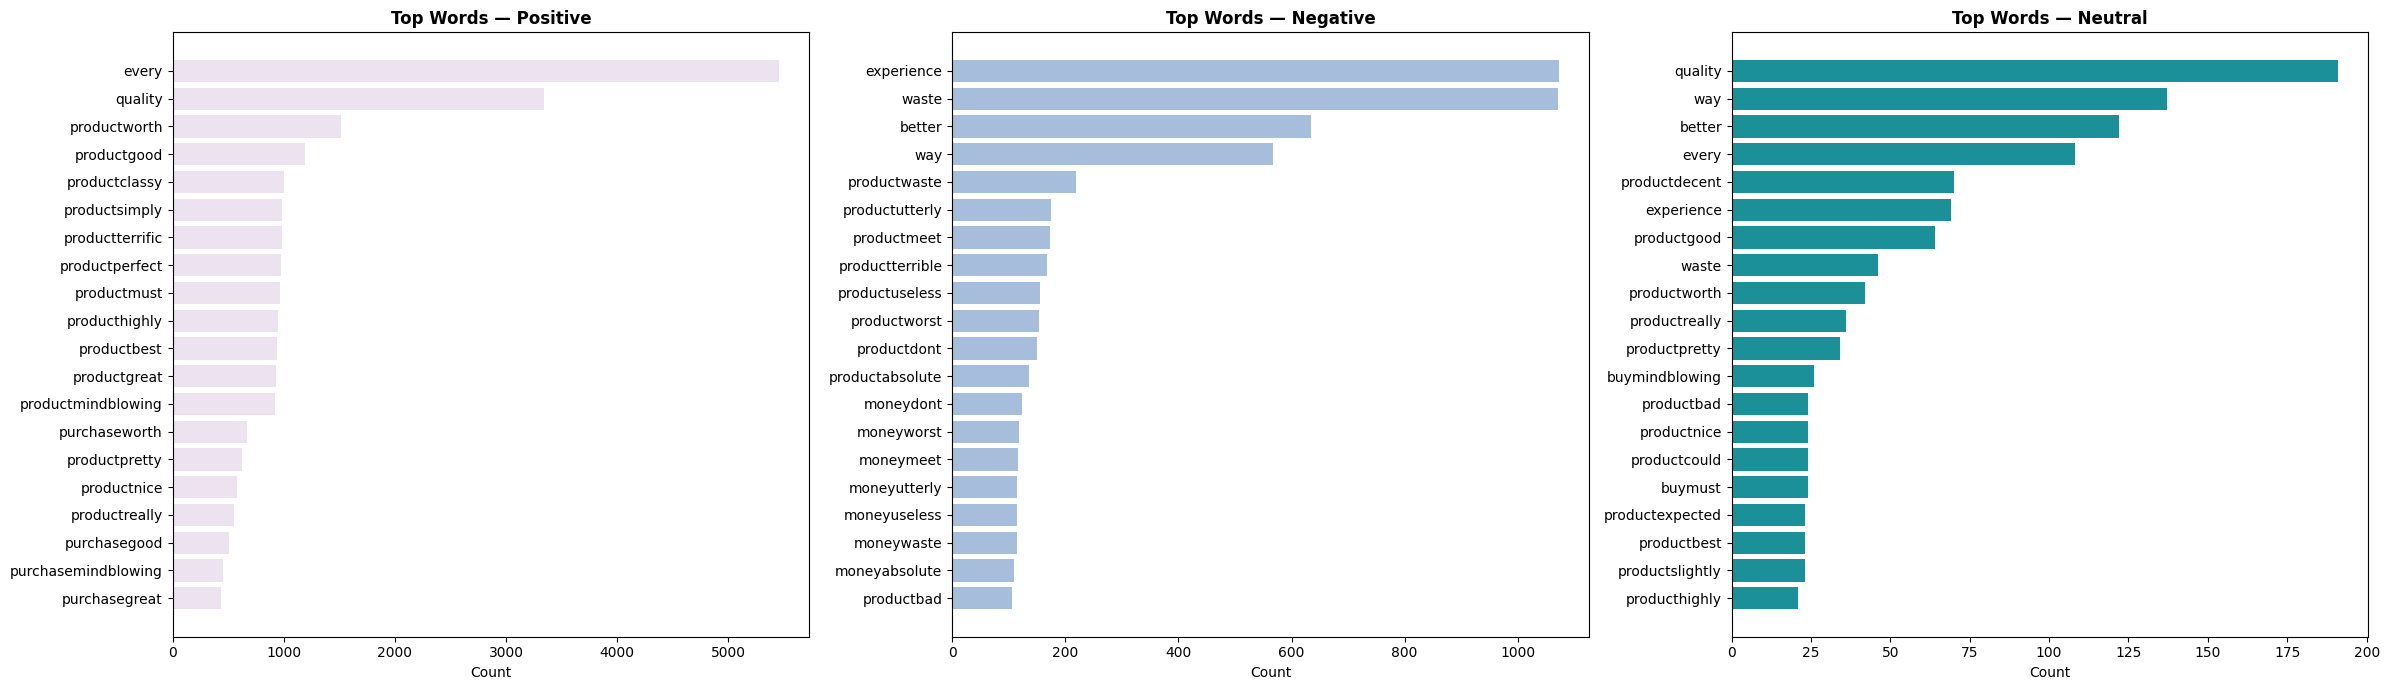

In [45]:

fig, axes = plt.subplots(1,3,figsize=(24,7))
data=[pos_split,neg_split,neu_split]
color=["#ece2f0","#a6bddb","#1c9099"]
labels=["Positive","Negative","Neutral"]
for ax,dt,clr,lbl in zip(axes,data,color,labels):
  w,c = zip(*dt)
  ax.barh(list(w)[::-1],list(c)[::-1],color=clr)
  ax.set_xlabel("Count")
  ax.set_title(f'Top Words — {lbl}', fontweight='bold')
plt.tight_layout()
plt.show()

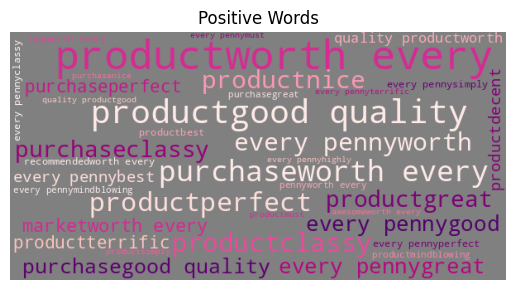

In [46]:
#World cloud

wc = WordCloud(width=600, height=300,background_color="grey", colormap="RdPu", max_words=80,
               min_font_size =10,contour_color='blue').generate(pos_words)

ax = plt.axes()
ax.imshow(wc)
ax.axis("off")
ax.set_title("Positive Words")
plt.show()

In [50]:
# Find classes with more than 1 sample
counts = y.value_counts()
valid_classes = counts[counts > 1].index

# Filter X and y
mask = y.isin(valid_classes)
X, y = X[mask], y[mask]


In [52]:
#TF-IDF
X = df["clean_text"]
y = df["Rate"]

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),min_df=2)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (144303,), Test: (36076,)


In [80]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"Train matrix size: {X_train_tfidf.shape}")
print(f"Test matrix size: {X_test_tfidf.shape}")

Train matrix size: (144303, 687)
Test matrix size: (36076, 687)


In [54]:
#log reg
clf = LogisticRegression(max_iter=2000)
clf.fit(tfidf.fit_transform(X_train), y_train)

LogisticRegression(max_iter=2000)

In [81]:
#predict
y_pred = clf.predict(X_test_tfidf)
y_pred = clf.predict(tfidf.transform(X_test))

In [85]:
# Check the accuracy score
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc: .2%}')


Accuracy:  93.59%


In [62]:
con_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=["Pos","Neg","Neu"])
disp.plot

<bound method ConfusionMatrixDisplay.plot of <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x7dac707c5700>>

In [65]:
summary="i honestly liked the productbest desert cooler..."

In [67]:
word_token = word_tokenize(summary)
print("word_token:", word_token)

word_token: ['i', 'honestly', 'liked', 'the', 'productbest', 'desert', 'cooler', '...']


In [71]:
sent_tokens = sent_tokenize(summary)
print("sent_tokens:", sent_tokens)

sent_tokens: ['i honestly liked the productbest desert cooler...']


In [74]:
#sample
sample = df['Summary'].iloc[0]

In [78]:
test_words = ["running", "flies", "happily", "denied", "agreed"]
stemmer = PorterStemmer()
#reduces words to their root
lemmatizer = WordNetLemmatizer()
#reduces words to their dictionary base form (lemma)


for word in test_words:                                   # loop over the list
    stemmed    = stemmer.stem(word)                       #  word, not words
    lemmatized = lemmatizer.lemmatize(word, pos='v')
    print(f'{word:<15}{stemmed:<15}{lemmatized:<15}')   #<15 means “left-align text and give it 15 spaces”


#print("." *45)


running        run            run            
flies          fli            fly            
happily        happili        happily        
denied         deni           deny           
agreed         agre           agree          
